In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ast 
from datasets import load_dataset
import seaborn as sns


In [7]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [8]:
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [10]:
df_INDIA = df[(df['job_country'] == 'India' ) & ( df['job_title_short'] == 'Data Analyst')].copy()

In [21]:
df_INDIA['job_location'].str.split(',').str[-2].str.strip()

def get_state(location):
    if pd.isna(location):
        return location

    parts = [x.strip() for x in location.split(',')]

    if len(parts) == 1:
        return parts[0]

    if len(parts) == 2:
        return parts[0]

    else: return parts[-2]
        

In [23]:
df_INDIA['job_states'] = df_INDIA['job_location'].apply(get_state)
df_INDIA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_states
38,Data Analyst,Data Quality and Governance Analyst 1,India,via Trabajo.org,Full-time,False,India,2023-07-23 13:24:57,False,False,India,NaN,NaN,NaN,"Jones Lang LaSalle IP, Inc","[sql, python, databricks, power bi, excel, wor...","{'analyst_tools': ['power bi', 'excel', 'word'...",India
123,Data Analyst,Data Analytics work from home job/internship a...,Anywhere,via LinkedIn,Part-time,True,India,2023-03-07 13:37:56,False,False,India,NaN,NaN,NaN,Inoket Solutions Private Limited,"[sql, excel, word, powerpoint, outlook, power bi]","{'analyst_tools': ['excel', 'word', 'powerpoin...",Anywhere
159,Data Analyst,Data Analyst,"Hyderabad, Telangana, India",via LinkedIn,Contractor,False,India,2023-11-28 13:12:07,False,False,India,NaN,NaN,NaN,Fusion Plus Solutions Inc,[sql],{'programming': ['sql']},Telangana
171,Data Analyst,Data Base work from home job/internship at Mga...,Anywhere,via LinkedIn,Full-time,True,India,2023-01-14 13:11:58,False,False,India,NaN,NaN,NaN,Mgadz Inc,"[sas, sas, sql]","{'analyst_tools': ['sas'], 'programming': ['sa...",Anywhere
194,Data Analyst,Data Analyst,India,via BeBee India,Full-time,False,India,2023-06-20 13:11:10,False,False,India,NaN,NaN,NaN,QuEST Global Services Pte. Ltd,"[python, sql, excel, ms access, powerpoint]","{'analyst_tools': ['excel', 'ms access', 'powe...",India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785517,Data Analyst,Analyst - Data Analytics/SQL (2-9 yrs),"Gurugram, Haryana, India",via BeBee India,Full-time,False,India,2023-10-16 06:10:56,False,False,India,NaN,NaN,NaN,iimjobs,[power bi],{'analyst_tools': ['power bi']},Haryana
785548,Data Analyst,Data Analyst,"Bengaluru, Karnataka, India",via LinkedIn,Full-time,False,India,2023-01-19 06:14:17,False,False,India,NaN,NaN,NaN,Artech L.L.C.,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['...",Karnataka
785628,Data Analyst,Data Analyst,"Gurugram, Haryana, India",via LinkedIn,Full-time,False,India,2023-01-09 06:08:12,False,False,India,NaN,NaN,NaN,GUS Global Services India Pvt. Ltd.,"[r, python, sql, sap, power bi, tableau, excel]","{'analyst_tools': ['sap', 'power bi', 'tableau...",Haryana
785691,Data Analyst,Business Intelligence Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-23 06:12:09,False,False,India,NaN,NaN,NaN,Mobile Programming LLC,"[sql, python, shell, sql server, tableau, micr...","{'analyst_tools': ['tableau', 'microstrategy']...",Tamil Nadu


Text(0, 0.5, '')

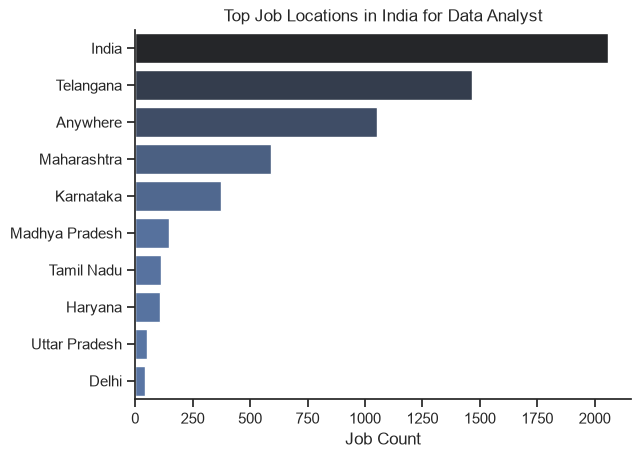

In [61]:
df_INDIA_plot = df_INDIA['job_states'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data= df_INDIA_plot , y= df_INDIA_plot.index , x= 'count', hue='count', palette='dark:b_r', legend= False)
sns.despine()
plt.title('Top Job Locations in India for Data Analyst')
plt.xlabel('Job Count')
plt.ylabel("")

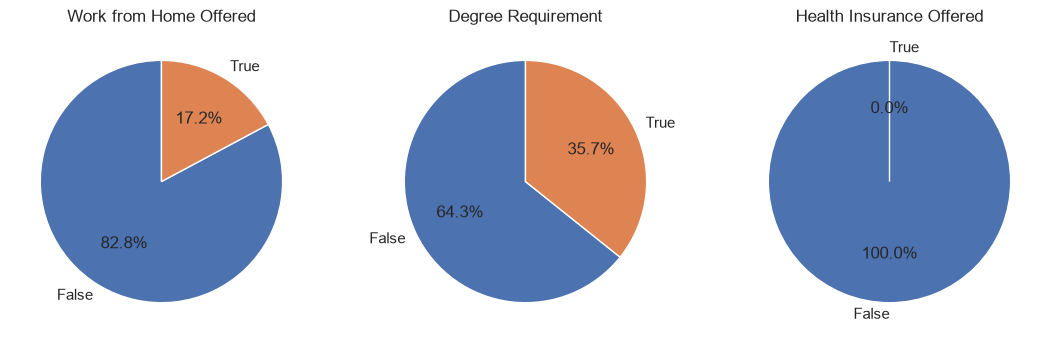

In [60]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):

    counts = df_INDIA[column].value_counts().reindex([False, True], fill_value=0)

    ax[i].pie(
    counts,
    labels=['False', 'True'],
    autopct='%1.1f%%',
    startangle=90
)

    ax[i].set_title(title)

plt.tight_layout()
plt.show()

Text(0, 0.5, '')

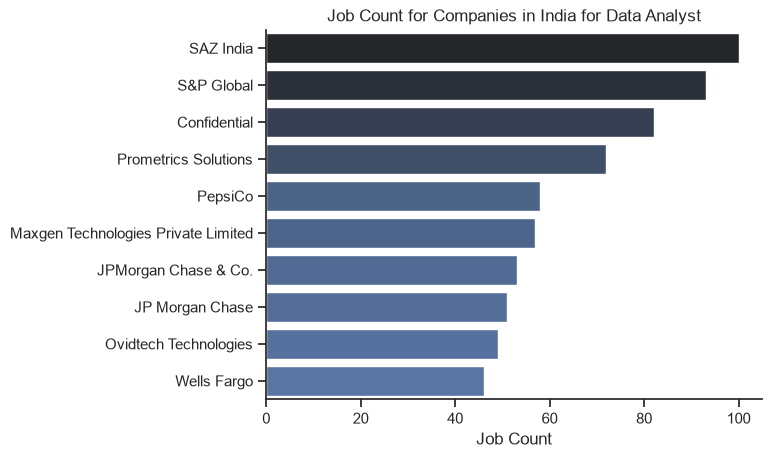

In [66]:
df_INDIA_plot = df_INDIA['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data= df_INDIA_plot , y= 'company_name' , x= 'count', hue='count', palette='dark:b_r', legend= False)
sns.despine()
plt.title('Job Count for Companies in India for Data Analyst')
plt.xlabel('Job Count')
plt.ylabel("")